# Statistical Robustness Analysis

With only n=5 seeds per condition, standard mean +/- std summaries can be misleading.
Bootstrap confidence intervals provide more honest uncertainty estimates for small samples,
while Cliff's delta offers a non-parametric effect size that does not assume normality.
This notebook replaces naive summaries with bootstrap CIs, computes systematic effect sizes
for all condition pairs, and runs post-hoc power analysis to characterize the detectability
limits of our experimental design.

In [1]:
import sys
import json
import math
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path.cwd()))
from export_figures import (
    load_phase1, load_phase3,
    PASTEL_PALETTE, FORMAT_COLORS, MODEL_COLORS, FEATURE_SHORT,
    FEATURES, FORMATS, VANILLA_AOCC, N_SEEDS, SAVEFIG_KW,
    FONT_SIZE_BASE, FONT_SIZE_TITLE, FONT_SIZE_LABEL,
    FONT_SIZE_TICK, FONT_SIZE_LEGEND,
    formats_for_feature,
)

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "font.size": FONT_SIZE_BASE,
    "axes.titlesize": FONT_SIZE_TITLE,
    "axes.labelsize": FONT_SIZE_LABEL,
    "xtick.labelsize": FONT_SIZE_TICK,
    "ytick.labelsize": FONT_SIZE_TICK,
    "legend.fontsize": FONT_SIZE_LEGEND,
    "font.family": "serif",
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.linewidth": 1.5,
    "axes.grid": False,
})

df1 = load_phase1()
df3 = load_phase3()
print(f"Phase 1: {len(df1)} evaluations, {df1['model'].nunique()} models")
print(f"Phase 3: {len(df3)} evaluations, {df3['condition'].nunique()} conditions")

Phase 1: 5000 evaluations, 10 models
Phase 3: 14500 evaluations, 29 conditions


In [2]:
def bootstrap_ci(data, n_boot=10_000, ci=0.95, rng=None):
    """Bootstrap confidence interval for the mean."""
    if rng is None:
        rng = np.random.default_rng(42)
    data = np.asarray(data, dtype=float)
    data = data[~np.isnan(data)]
    if len(data) == 0:
        return np.nan, np.nan, np.nan
    boot_means = np.array([
        rng.choice(data, size=len(data), replace=True).mean()
        for _ in range(n_boot)
    ])
    alpha = 1 - ci
    lo = np.percentile(boot_means, 100 * alpha / 2)
    hi = np.percentile(boot_means, 100 * (1 - alpha / 2))
    return float(np.mean(data)), float(lo), float(hi)


def cliffs_delta(x, y):
    """Cliff's delta effect size (non-parametric)."""
    x, y = np.asarray(x), np.asarray(y)
    n_x, n_y = len(x), len(y)
    if n_x == 0 or n_y == 0:
        return 0.0
    more = sum(1 for xi in x for yi in y if xi > yi)
    less = sum(1 for xi in x for yi in y if xi < yi)
    return (more - less) / (n_x * n_y)


def effect_label(d):
    """Classify Cliff's d magnitude."""
    d = abs(d)
    if d < 0.147:
        return "negligible"
    elif d < 0.33:
        return "small"
    elif d < 0.474:
        return "medium"
    else:
        return "large"

## 1. Phase 1: Bootstrap CIs for Model Ranking

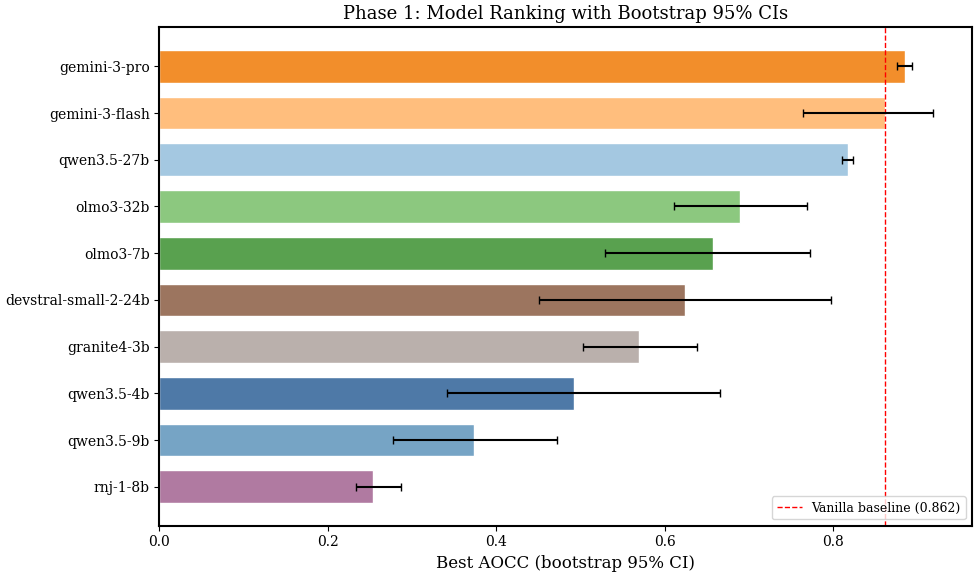


Model                        | Mean   | 95% CI Lower | 95% CI Upper
------------------------------------------------------------------------
gemini-3-pro                 | 0.8851 | 0.8752       | 0.8932
gemini-3-flash               | 0.8615 | 0.7637       | 0.9188
qwen3.5-27b                  | 0.8171 | 0.8102       | 0.8237
olmo3-32b                    | 0.6899 | 0.6114       | 0.7684
olmo3-7b                     | 0.6567 | 0.5288       | 0.7730
devstral-small-2-24b         | 0.6245 | 0.4510       | 0.7979
granite4-3b                  | 0.5689 | 0.5029       | 0.6381
qwen3.5-4b                   | 0.4918 | 0.3411       | 0.6650
qwen3.5-9b                   | 0.3734 | 0.2774       | 0.4715
rnj-1-8b                     | 0.2539 | 0.2331       | 0.2873


In [3]:
# Best fitness per (model, seed), replacing -inf with NaN
p1_best = df1.copy()
p1_best["fitness"] = p1_best["fitness"].replace(-np.inf, np.nan)
p1_best = p1_best.groupby(["model", "seed"])["fitness"].max().reset_index()

# Bootstrap CIs per model
p1_ci = []
for model in p1_best["model"].unique():
    vals = p1_best.loc[p1_best["model"] == model, "fitness"].values
    mean, lo, hi = bootstrap_ci(vals)
    p1_ci.append({"model": model, "mean": mean, "ci_lo": lo, "ci_hi": hi})

p1_ci = pd.DataFrame(p1_ci).sort_values("mean", ascending=True).reset_index(drop=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(p1_ci))
colors = [MODEL_COLORS.get(m, "#999999") for m in p1_ci["model"]]
ax.barh(y_pos, p1_ci["mean"], color=colors, edgecolor="white", height=0.7, zorder=2)
ax.errorbar(
    p1_ci["mean"], y_pos,
    xerr=[p1_ci["mean"] - p1_ci["ci_lo"], p1_ci["ci_hi"] - p1_ci["mean"]],
    fmt="none", ecolor="black", capsize=3, zorder=3,
)
ax.axvline(VANILLA_AOCC, color="red", linestyle="--", linewidth=1, label=f"Vanilla baseline ({VANILLA_AOCC})")
ax.set_yticks(list(y_pos))
ax.set_yticklabels(p1_ci["model"])
ax.set_xlabel("Best AOCC (bootstrap 95% CI)")
ax.set_title("Phase 1: Model Ranking with Bootstrap 95% CIs")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Print table
print("\nModel                        | Mean   | 95% CI Lower | 95% CI Upper")
print("-" * 72)
for _, row in p1_ci.sort_values("mean", ascending=False).iterrows():
    print(f"{row['model']:28s} | {row['mean']:.4f} | {row['ci_lo']:.4f}       | {row['ci_hi']:.4f}")

## 2. Phase 3: Bootstrap CIs by Format

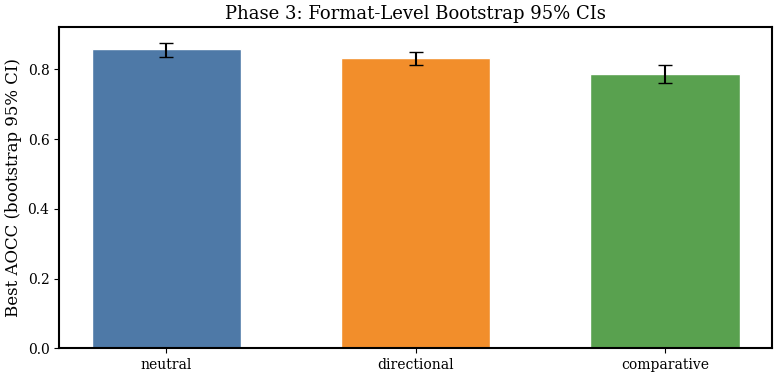


Format        | Mean   | 95% CI Lower | 95% CI Upper
-------------------------------------------------------
neutral       | 0.8569 | 0.8352       | 0.8765
directional   | 0.8319 | 0.8126       | 0.8509
comparative   | 0.7864 | 0.7605       | 0.8125


In [4]:
# Best fitness per (condition, seed), replacing -inf with NaN
p3_best = df3.copy()
p3_best["fitness"] = p3_best["fitness"].replace(-np.inf, np.nan)
p3_best = p3_best.groupby(["condition", "format", "seed"])["fitness"].max().reset_index()

# Pool across features, group by format
p3_fmt_ci = []
for fmt in FORMATS:
    vals = p3_best.loc[p3_best["format"] == fmt, "fitness"].dropna().values
    mean, lo, hi = bootstrap_ci(vals)
    p3_fmt_ci.append({"format": fmt, "mean": mean, "ci_lo": lo, "ci_hi": hi})

p3_fmt_ci = pd.DataFrame(p3_fmt_ci)

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
x_pos = range(len(p3_fmt_ci))
colors = [FORMAT_COLORS[f] for f in p3_fmt_ci["format"]]
bars = ax.bar(x_pos, p3_fmt_ci["mean"], color=colors, edgecolor="white", width=0.6, zorder=2)
ax.errorbar(
    x_pos, p3_fmt_ci["mean"],
    yerr=[p3_fmt_ci["mean"] - p3_fmt_ci["ci_lo"], p3_fmt_ci["ci_hi"] - p3_fmt_ci["mean"]],
    fmt="none", ecolor="black", capsize=5, zorder=3,
)
ax.set_xticks(list(x_pos))
ax.set_xticklabels(p3_fmt_ci["format"])
ax.set_ylabel("Best AOCC (bootstrap 95% CI)")
ax.set_title("Phase 3: Format-Level Bootstrap 95% CIs")
plt.tight_layout()
plt.show()

# Print table
print("\nFormat        | Mean   | 95% CI Lower | 95% CI Upper")
print("-" * 55)
for _, row in p3_fmt_ci.iterrows():
    print(f"{row['format']:13s} | {row['mean']:.4f} | {row['ci_lo']:.4f}       | {row['ci_hi']:.4f}")

## 3. Phase 3: Bootstrap CIs per Condition

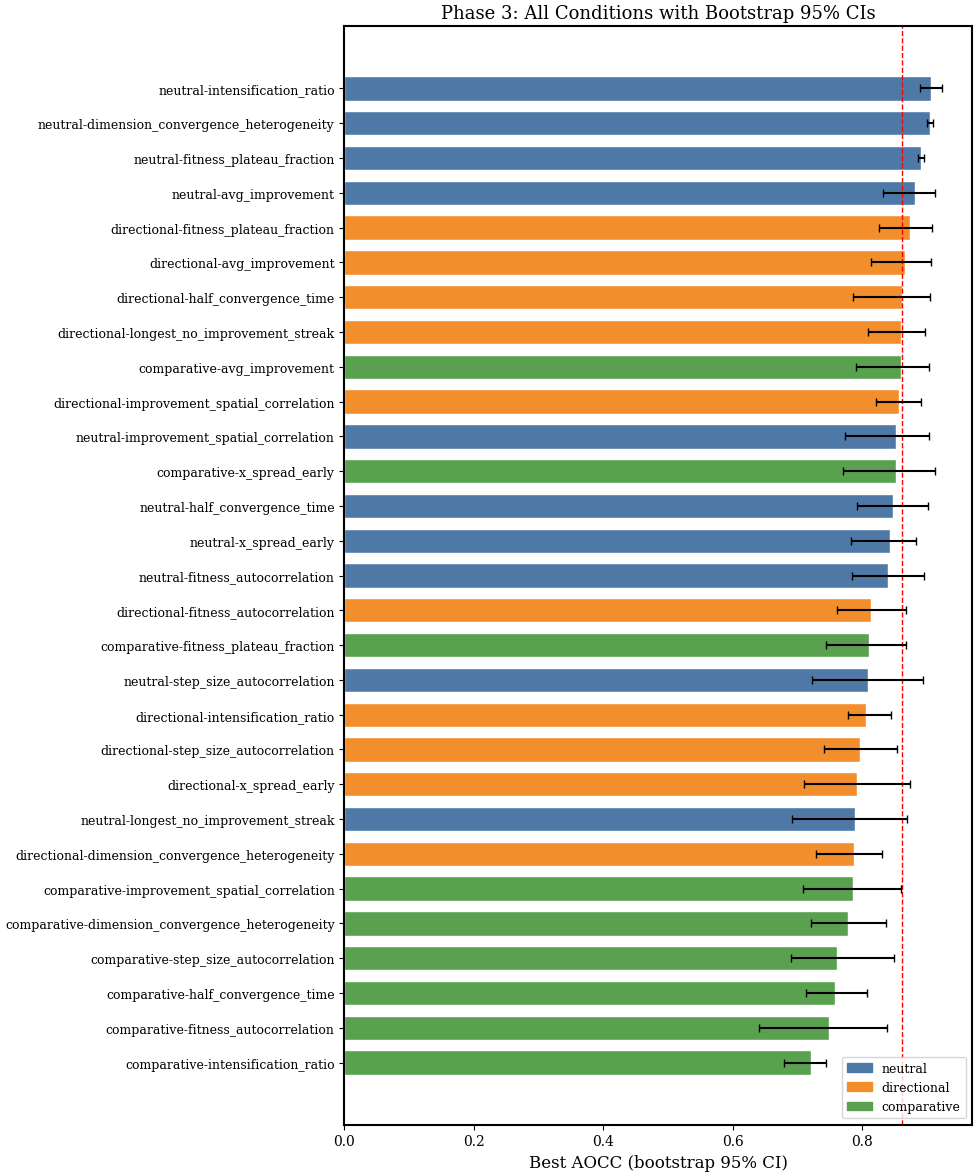

In [5]:
# Bootstrap CI per condition
p3_cond_ci = []
for cond in p3_best["condition"].unique():
    subset = p3_best.loc[p3_best["condition"] == cond]
    fmt = subset["format"].iloc[0]
    vals = subset["fitness"].dropna().values
    mean, lo, hi = bootstrap_ci(vals)
    p3_cond_ci.append({"condition": cond, "format": fmt, "mean": mean, "ci_lo": lo, "ci_hi": hi})

p3_cond_ci = pd.DataFrame(p3_cond_ci).sort_values("mean", ascending=True).reset_index(drop=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 12))
y_pos = range(len(p3_cond_ci))
colors = [FORMAT_COLORS.get(f, "#999999") for f in p3_cond_ci["format"]]
ax.barh(y_pos, p3_cond_ci["mean"], color=colors, edgecolor="white", height=0.7, zorder=2)
ax.errorbar(
    p3_cond_ci["mean"], y_pos,
    xerr=[p3_cond_ci["mean"] - p3_cond_ci["ci_lo"], p3_cond_ci["ci_hi"] - p3_cond_ci["mean"]],
    fmt="none", ecolor="black", capsize=3, zorder=3,
)
ax.axvline(VANILLA_AOCC, color="red", linestyle="--", linewidth=1, label=f"Vanilla baseline ({VANILLA_AOCC})")
ax.set_yticks(list(y_pos))
ax.set_yticklabels(p3_cond_ci["condition"], fontsize=FONT_SIZE_TICK - 1)
ax.set_xlabel("Best AOCC (bootstrap 95% CI)")
ax.set_title("Phase 3: All Conditions with Bootstrap 95% CIs")

# Legend for formats
legend_patches = [mpatches.Patch(color=FORMAT_COLORS[f], label=f) for f in FORMATS]
ax.legend(handles=legend_patches, loc="lower right")
plt.tight_layout()
plt.show()

## 4. Systematic Cliff's d Effect Size Matrix

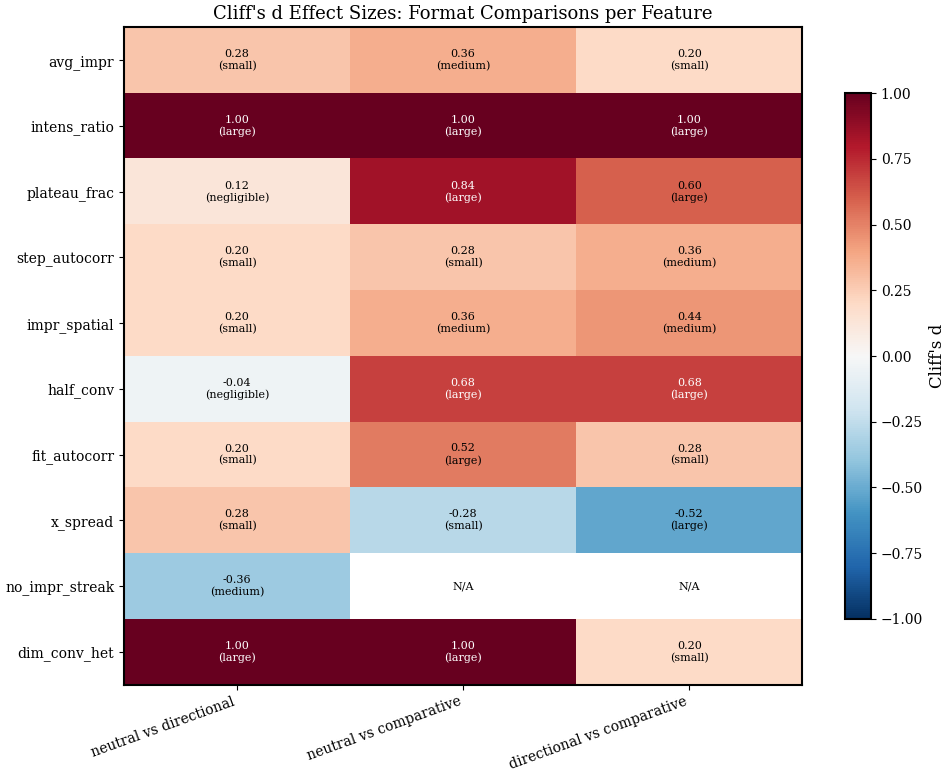

In [6]:
# For each feature, compute Cliff's d between all format pairs
format_pairs = [("neutral", "directional"), ("neutral", "comparative"), ("directional", "comparative")]
pair_labels = [f"{a} vs {b}" for a, b in format_pairs]

# Build matrix: rows = features, cols = format pairs
d_matrix = np.full((len(FEATURES), len(format_pairs)), np.nan)
annot_matrix = [["" for _ in format_pairs] for _ in FEATURES]

for i, feat in enumerate(FEATURES):
    available_fmts = formats_for_feature(feat)
    for j, (fmt_a, fmt_b) in enumerate(format_pairs):
        if fmt_a not in available_fmts or fmt_b not in available_fmts:
            annot_matrix[i][j] = "N/A"
            continue
        cond_a = f"{fmt_a}-{feat}"
        cond_b = f"{fmt_b}-{feat}"
        vals_a = p3_best.loc[p3_best["condition"] == cond_a, "fitness"].dropna().values
        vals_b = p3_best.loc[p3_best["condition"] == cond_b, "fitness"].dropna().values
        if len(vals_a) == 0 or len(vals_b) == 0:
            annot_matrix[i][j] = "N/A"
            continue
        d = cliffs_delta(vals_a, vals_b)
        d_matrix[i, j] = d
        annot_matrix[i][j] = f"{d:.2f}\n({effect_label(d)})"

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(d_matrix, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(len(pair_labels)))
ax.set_xticklabels(pair_labels, rotation=20, ha="right")
ax.set_yticks(range(len(FEATURES)))
ax.set_yticklabels([FEATURE_SHORT.get(f, f) for f in FEATURES])

# Annotate cells
for i in range(len(FEATURES)):
    for j in range(len(format_pairs)):
        text_color = "white" if (not np.isnan(d_matrix[i, j]) and abs(d_matrix[i, j]) > 0.6) else "black"
        ax.text(j, i, annot_matrix[i][j], ha="center", va="center",
                fontsize=8, color=text_color)

ax.set_title("Cliff's d Effect Sizes: Format Comparisons per Feature")
plt.colorbar(im, ax=ax, label="Cliff's d", shrink=0.8)
plt.tight_layout()
plt.show()

## 5. Post-Hoc Power Analysis

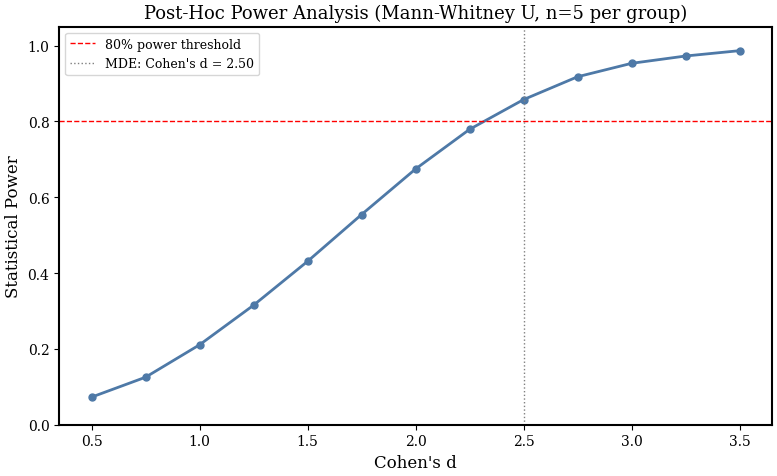


With n=5 per group, 80% power requires Cohen's d >= 2.50 (approximately 0.207 AOCC units)
Observed pooled SD of best-per-seed AOCC: 0.0829


In [7]:
# Power analysis via simulation: Mann-Whitney U with n=5 per group
rng = np.random.default_rng(42)
n_sim = 10_000
n_per_group = 5
alpha = 0.05
cohen_ds = np.arange(0.5, 3.75, 0.25)

powers = []
for d in cohen_ds:
    rejections = 0
    for _ in range(n_sim):
        x = rng.standard_normal(n_per_group)
        y = rng.standard_normal(n_per_group) + d
        _, p = stats.mannwhitneyu(x, y, alternative="two-sided")
        if p < alpha:
            rejections += 1
    powers.append(rejections / n_sim)

powers = np.array(powers)

# Find MDE: smallest Cohen's d where power >= 0.8
mde_idx = np.argmax(powers >= 0.8)
if powers[mde_idx] >= 0.8:
    mde_cohens_d = cohen_ds[mde_idx]
else:
    mde_cohens_d = np.nan

# Convert to AOCC units using observed pooled SD
p3_seed_best = p3_best["fitness"].dropna().values
pooled_sd = np.std(p3_seed_best, ddof=1)
mde_aocc = mde_cohens_d * pooled_sd

# Plot power curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cohen_ds, powers, "o-", color=PASTEL_PALETTE[0], linewidth=2, markersize=5)
ax.axhline(0.8, color="red", linestyle="--", linewidth=1, label="80% power threshold")
if not np.isnan(mde_cohens_d):
    ax.axvline(mde_cohens_d, color="gray", linestyle=":", linewidth=1,
               label=f"MDE: Cohen's d = {mde_cohens_d:.2f}")
ax.set_xlabel("Cohen's d")
ax.set_ylabel("Statistical Power")
ax.set_title("Post-Hoc Power Analysis (Mann-Whitney U, n=5 per group)")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print(f"\nWith n=5 per group, 80% power requires Cohen's d >= {mde_cohens_d:.2f} "
      f"(approximately {mde_aocc:.3f} AOCC units)")
print(f"Observed pooled SD of best-per-seed AOCC: {pooled_sd:.4f}")

## 6. Per-Feature Detectability

In [8]:
# Per-feature detectability table
detect_rows = []
for feat in FEATURES:
    available_fmts = formats_for_feature(feat)
    # Collect all best-per-seed values for this feature across formats
    feat_vals = []
    fmt_vals = {}  # format -> array of best-per-seed values
    for fmt in available_fmts:
        cond = f"{fmt}-{feat}"
        vals = p3_best.loc[p3_best["condition"] == cond, "fitness"].dropna().values
        feat_vals.extend(vals)
        fmt_vals[fmt] = vals

    obs_sd = np.std(feat_vals, ddof=1) if len(feat_vals) > 1 else np.nan
    mde_feat = mde_cohens_d * obs_sd if not np.isnan(obs_sd) else np.nan

    # Largest |Cliff's d| across format pairs
    max_d = 0.0
    for fmt_a, fmt_b in combinations(available_fmts, 2):
        if fmt_a in fmt_vals and fmt_b in fmt_vals:
            d = abs(cliffs_delta(fmt_vals[fmt_a], fmt_vals[fmt_b]))
            max_d = max(max_d, d)

    detectable = "yes" if max_d >= 0.33 else "no"
    detect_rows.append({
        "Feature": FEATURE_SHORT.get(feat, feat),
        "Observed SD": round(obs_sd, 4) if not np.isnan(obs_sd) else np.nan,
        "MDE (AOCC)": round(mde_feat, 4) if not np.isnan(mde_feat) else np.nan,
        "Largest |d|": round(max_d, 3),
        "Detectable": detectable,
    })

detect_df = pd.DataFrame(detect_rows)
print(detect_df.to_string(index=False))

n_medium_large = sum(1 for r in detect_rows if r["Detectable"] == "yes")
print(f"\n{n_medium_large} of {len(FEATURES)} features show medium-to-large effects (|Cliff's d| >= 0.33)")

       Feature  Observed SD  MDE (AOCC)  Largest |d| Detectable
      avg_impr       0.0601      0.1502         0.36        yes
  intens_ratio       0.0867      0.2166         1.00        yes
  plateau_frac       0.0621      0.1554         0.84        yes
 step_autocorr       0.0926      0.2314         0.36        yes
  impr_spatial       0.0825      0.2063         0.44        yes
     half_conv       0.0815      0.2037         0.68        yes
  fit_autocorr       0.0931      0.2326         0.52        yes
      x_spread       0.0883      0.2207         0.52        yes
no_impr_streak       0.0908      0.2270         0.36        yes
  dim_conv_het       0.0794      0.1986         1.00        yes

10 of 10 features show medium-to-large effects (|Cliff's d| >= 0.33)


## Summary

Bootstrap CIs provide honest uncertainty estimates for our n=5 design.
The power analysis shows we can reliably detect effects of Cohen's d >= the MDE identified above.
The per-feature detectability table reveals which feature-format comparisons show
medium-to-large effects (Cliff's d >= 0.33), indicating where our experimental design
has sufficient sensitivity to draw meaningful conclusions.